# Stage 8: Individual-Predictor Interpretation

Stage 8 interprets the fixed MLR and RF models using the 69 pre-transition predictors.

MLR is examined through class-specific coefficients and class contrasts. RF is examined with TreeSHAP on the predicted-probability scale. The held-out sample is used only after model development and final evaluation are complete.


## Part 1: Inputs and analysis sample


In [1]:
# 1: Import packages and set project paths

from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from IPython.display import display
from scipy import sparse
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

working_directory = Path.cwd().resolve()

project_root = next(
    (
        directory
        for directory in [working_directory, *working_directory.parents]
        if (
            directory
            / "data_derived"
            / "stage_3_final_modelling_dataset"
            / "final_modelling_dataset.csv"
        ).is_file()
        and (
            directory
            / "data_derived"
            / "stage_6_held_out_test_evaluation"
            / "stage_6_frozen_model_specifications.csv"
        ).is_file()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError("Required Stage 3 and Stage 6 inputs could not be located.")

data_derived = project_root / "data_derived"

stage_2_dir = data_derived / "stage_2_predictor_construction"
stage_3_dir = data_derived / "stage_3_final_modelling_dataset"
stage_4_dir = data_derived / "stage_4_modelling_design"
stage_6_dir = data_derived / "stage_6_held_out_test_evaluation"
stage_8_dir = data_derived / "stage_8_shap_interpretation"

stage_8_dir.mkdir(parents=True, exist_ok=True)

print("SHAP version:", shap.__version__)


SHAP version: 0.49.1


In [2]:
# 2: Define the required files

# Use only the fixed modelling and interpretation inputs.
paths = {
    "data": stage_3_dir / "final_modelling_dataset.csv",
    "split": stage_4_dir / "stage_4_train_test_split.csv",
    "roles": stage_4_dir / "stage_4_predictor_preprocessing_roles.csv",
    "search": stage_4_dir / "stage_4_model_search_specification.csv",
    "model specifications": stage_6_dir / "stage_6_frozen_model_specifications.csv",
    "test predictions": stage_6_dir / "stage_6_test_predictions.csv",
    "predictor manifest": stage_2_dir / "stage_2_final_predictor_manifest.csv",
}

missing = [name for name, path in paths.items() if not path.is_file()]

if missing:
    raise FileNotFoundError("Missing input file(s): " + ", ".join(missing))

print("Required files:", len(paths))


Required files: 7


In [3]:
# 3: Load the modelling records

# Read the data and fixed design tables.
data = pd.read_csv(paths["data"], dtype={"NSID": "string"})
split = pd.read_csv(paths["split"], dtype={"NSID": "string"})
roles = pd.read_csv(paths["roles"])
search_spec = pd.read_csv(paths["search"])
model_spec = pd.read_csv(paths["model specifications"])
stage_6_predictions = pd.read_csv(
    paths["test predictions"],
    dtype={"NSID": "string"},
)
predictor_manifest = pd.read_csv(paths["predictor manifest"])

print("Modelling participants:", len(data))
print("Registered predictors:", len(roles))


Modelling participants: 9524
Registered predictors: 69


In [4]:
# 4: Create the training and test samples

# Apply the fixed participant split from Stage 4.
train_ids = set(split.loc[split["sample"].eq("Training"), "NSID"])
test_ids = set(split.loc[split["sample"].eq("Test"), "NSID"])

train = data.loc[data["NSID"].isin(train_ids)].copy().reset_index(drop=True)
test = data.loc[data["NSID"].isin(test_ids)].copy().reset_index(drop=True)

predictors = roles["Predictor"].tolist()
numeric = roles.loc[
    roles["Preprocessing role"].eq("Numeric"),
    "Predictor",
].tolist()
categorical = roles.loc[
    roles["Preprocessing role"].eq("Categorical"),
    "Predictor",
].tolist()

for predictor in numeric:
    train[predictor] = pd.to_numeric(train[predictor], errors="raise")
    test[predictor] = pd.to_numeric(test[predictor], errors="raise")

print("Training participants:", len(train))
print("Test participants:", len(test))
print("Predictors:", len(predictors))


Training participants: 7619
Test participants: 1905
Predictors: 69


In [5]:
# 5: Set the four outcome labels

# Map the survey outcome codes to the model class numbers.
outcome_labels = {
    0: "Education",
    1: "Employment",
    2: "Apprenticeship or training",
    3: "Unemployment or inactivity (NEET)",
}

code_to_class = {1: 0, 4: 1, 5: 2, 6: 3}

train["y"] = train["age18_outcome_code"].map(code_to_class).astype(int)
test["y"] = test["age18_outcome_code"].map(code_to_class).astype(int)

print(train["y"].value_counts().sort_index())


y
0    3961
1    2241
2     416
3    1001
Name: count, dtype: int64


In [6]:
# 6: Check the analysis inputs

# Confirm the fixed sample and predictor structure.
checks = {
    "9,524 modelling participants": len(data) == 9_524,
    "7,619 training participants": len(train) == 7_619,
    "1,905 test participants": len(test) == 1_905,
    "69 predictors": len(predictors) == 69,
    "Predictor names are unique": roles["Predictor"].is_unique,
    "Predictors are present": set(predictors).issubset(data.columns),
    "Training and test do not overlap": train_ids.isdisjoint(test_ids),
    "Four outcome classes": set(train["y"]) == {0, 1, 2, 3},
}

input_audit = pd.DataFrame({
    "Check": checks.keys(),
    "Passed": checks.values(),
})

display(input_audit)

if not input_audit["Passed"].all():
    raise AssertionError("Stage 8 input check failed.")


,Check,Passed
0,"9,524 modelling participants",True
1,"7,619 training participants",True
2,"1,905 test participants",True
3,69 predictors,True
4,Predictor names are unique,True
5,Predictors are present,True
6,Training and test do not overlap,True
7,Four outcome classes,True


## Part 2: Fixed model fitting

The fixed MLR and RF specifications are refitted on the training sample and must reproduce the saved Stage 6 predictions and probabilities before interpretation.

In [7]:
# 1: Read the fixed model random state

# Use the RF random state registered in the modelling design.
search_index = search_spec.set_index("Model")
rf_fixed = json.loads(search_index.loc["Random forest", "Fixed parameters"])
model_random_state = int(rf_fixed["random_state"])

print("Model random state:", model_random_state)


Model random state: 424242


In [8]:
# 2: Define model preprocessing

# Apply the registered preprocessing for each model family.
def make_preprocessor(model_name):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]

    if model_name == "MLR":
        numeric_steps.append(("scaler", StandardScaler()))

    return ColumnTransformer([
        ("numeric", Pipeline(numeric_steps), numeric),
        ("categorical", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(
                handle_unknown="ignore",
                drop="if_binary",
            )),
        ]), categorical),
    ])


In [9]:
# 3: Define the two estimators

# Use the fixed Stage 6 model parameters.
def make_estimator(model_name, parameters, weighting):
    if model_name == "MLR":
        return LogisticRegression(
            C=float(parameters["C"]),
            solver="lbfgs",
            max_iter=3000,
            class_weight="balanced" if weighting == "Balanced" else None,
        )

    return RandomForestClassifier(
        **parameters,
        min_samples_split=2,
        class_weight="balanced" if weighting == "Balanced" else None,
        n_jobs=-1,
        random_state=model_random_state,
    )


In [10]:
# 4: Fit the fixed MLR and RF pipelines

# Fit each fixed model on all training participants.
models = {}

for model_name in ["MLR", "RF"]:
    row = model_spec.loc[model_spec["Model"].eq(model_name)].iloc[0]
    weighting = row["Selected weighting mode"]
    parameters = json.loads(row["Selected parameters"])

    pipe = Pipeline([
        ("preprocessor", make_preprocessor(model_name)),
        ("model", make_estimator(model_name, parameters, weighting)),
    ])

    pipe.fit(train[predictors], train["y"])
    models[model_name] = pipe

print("Models fitted:", list(models))


Models fitted: ['MLR', 'RF']


In [11]:
# 5: Check the held-out predictions

# Compare the fitted outputs with the saved Stage 6 results.
prediction_rows = []
probability_columns = [
    "Probability Education",
    "Probability Employment",
    "Probability Apprenticeship or training",
    "Probability Unemployment or inactivity (NEET)",
]

for model_name, pipe in models.items():
    stored = (
        stage_6_predictions.loc[stage_6_predictions["Model"].eq(model_name)]
        .set_index("NSID")
        .reindex(test["NSID"])
    )

    predicted = pipe.predict(test[predictors]).astype(int)
    probabilities = pipe.predict_proba(test[predictors])

    prediction_rows.append({
        "Model": model_name,
        "Predictions match": np.array_equal(
            predicted,
            stored["Predicted internal class"].to_numpy(dtype=int),
        ),
        "Probabilities match": np.allclose(
            probabilities,
            stored[probability_columns].to_numpy(),
            atol=1e-10,
            rtol=1e-8,
        ),
    })

prediction_audit = pd.DataFrame(prediction_rows)
display(prediction_audit)

if not prediction_audit[["Predictions match", "Probabilities match"]].all().all():
    raise AssertionError("Stage 6 predictions were not reproduced.")


,Model,Predictions match,Probabilities match
0,MLR,True,True
1,RF,True,True


In [12]:
# 6: Save the model reproduction check

# Record the reproduction check before interpretation.
prediction_audit.to_csv(
    stage_8_dir / "stage_8_model_reproduction.csv",
    index=False,
)

print("Saved model reproduction check.")


Saved model reproduction check.


## Part 3: MLR interpretation
MLR is interpreted using class-specific coefficients and pairwise class contrasts on the multinomial-logit scale. Coefficient magnitude is not used to rank predictors globally, and coefficient signs are not interpreted as direct changes in predicted probability.

In [13]:
# 1: Map transformed MLR features to original predictors

# Link each fitted MLR column to its original predictor.
mlr_preprocessor = models["MLR"].named_steps["preprocessor"]
mlr_feature_names = mlr_preprocessor.get_feature_names_out().tolist()
mlr_encoder = (
    mlr_preprocessor.named_transformers_["categorical"]
    .named_steps["encoder"]
)

mapping_rows = []
position = 0

for predictor in numeric:
    mapping_rows.append({
        "Position": position,
        "Transformed feature": mlr_feature_names[position],
        "Original predictor": predictor,
        "Category": pd.NA,
    })
    position += 1

for i, predictor in enumerate(categorical):
    dropped = None if mlr_encoder.drop_idx_ is None else mlr_encoder.drop_idx_[i]

    for j, category in enumerate(mlr_encoder.categories_[i]):
        if dropped is not None and j == dropped:
            continue

        mapping_rows.append({
            "Position": position,
            "Transformed feature": mlr_feature_names[position],
            "Original predictor": predictor,
            "Category": category,
        })
        position += 1

mlr_feature_map = pd.DataFrame(mapping_rows)

assert len(mlr_feature_map) == len(mlr_feature_names)
assert mlr_feature_map["Original predictor"].nunique() == 69

print("MLR transformed features:", len(mlr_feature_map))


MLR transformed features: 118


In [14]:
# 2: Create the class-specific coefficient table

# Keep coefficients in the fitted MLR representation.
mlr_estimator = models["MLR"].named_steps["model"]
coefficient_tables = []

for class_number, outcome in outcome_labels.items():
    table = mlr_feature_map.copy()
    table["Outcome"] = outcome
    table["Coefficient"] = mlr_estimator.coef_[class_number]
    coefficient_tables.append(table)

mlr_coefficients = pd.concat(coefficient_tables, ignore_index=True)

mlr_coefficients.to_csv(
    stage_8_dir / "stage_8_mlr_coefficients.csv",
    index=False,
)

display(mlr_coefficients.head())


,Position,Transformed feature,Original predictor,Category,Outcome,Coefficient
0,0,numeric__birth_month_position,birth_month_position,<NA>,Education,0.044382
1,1,numeric__highest_parental_qualification_code,highest_parental_qualification_code,<NA>,Education,-0.085737
2,2,numeric__household_income_band,household_income_band,<NA>,Education,-0.030949
3,3,numeric__working_parent_or_guardian_count,working_parent_or_guardian_count,<NA>,Education,-0.004476
4,4,numeric__sen_status_pretransition,sen_status_pretransition,<NA>,Education,0.004124


In [15]:
# 3: Create pairwise MLR class contrasts

# Subtract class coefficients to show fitted class-score contrasts.
contrast_tables = []

for first_class in range(4):
    for second_class in range(first_class + 1, 4):
        table = mlr_feature_map.copy()
        table["Outcome A"] = outcome_labels[first_class]
        table["Outcome B"] = outcome_labels[second_class]
        table["Coefficient difference A-B"] = (
            mlr_estimator.coef_[first_class]
            - mlr_estimator.coef_[second_class]
        )
        contrast_tables.append(table)

mlr_contrasts = pd.concat(contrast_tables, ignore_index=True)

mlr_contrasts.to_csv(
    stage_8_dir / "stage_8_mlr_class_contrasts.csv",
    index=False,
)

print("MLR class contrasts:", len(mlr_contrasts))


MLR class contrasts: 708


## Part 4: RF probability TreeSHAP

RF is explained on the predicted-probability scale using a training-sample background.


In [16]:
# 1: Select the training background

# Draw a reproducible background sample from the training distribution.
background_size = 500
background_index = train.sample(
    n=background_size,
    random_state=model_random_state,
).index

background_register = train.loc[
    background_index,
    ["NSID", "age18_outcome"],
].copy()

background_register.to_csv(
    stage_8_dir / "stage_8_shap_background.csv",
    index=False,
)

display(background_register["age18_outcome"].value_counts())


age18_outcome
Education                            247
Employment                           154
Unemployment or inactivity (NEET)     69
Apprenticeship or training            30
Name: count, dtype: int64

In [17]:
# 2: Prepare the transformed RF data

# Convert the fitted RF inputs to dense arrays for TreeSHAP.
def dense_array(values):
    if sparse.issparse(values):
        return values.toarray()
    return np.asarray(values)

rf_preprocessor = models["RF"].named_steps["preprocessor"]
rf_background = dense_array(
    rf_preprocessor.transform(train.loc[background_index, predictors])
)
rf_test = dense_array(
    rf_preprocessor.transform(test[predictors])
)
rf_feature_names = rf_preprocessor.get_feature_names_out().tolist()

print("Transformed RF features:", len(rf_feature_names))


Transformed RF features: 118


In [18]:
# 3: Build the RF probability explainer

# Explain RF probabilities using the training background.
rf_estimator = models["RF"].named_steps["model"]
rf_explainer = shap.TreeExplainer(
    rf_estimator,
    data=rf_background,
    feature_perturbation="interventional",
    model_output="probability",
)

print("RF probability explainer created.")


RF probability explainer created.


In [19]:
# 4: Check probability SHAP on a small subset

# Confirm four outputs and probability additivity before full calculation.
rf_small = rf_test[:10]
small_values = rf_explainer.shap_values(
    rf_small,
    check_additivity=False,
)

if isinstance(small_values, list):
    small_values = np.stack(small_values, axis=-1)

small_values = np.asarray(small_values)
expected = np.asarray(rf_explainer.expected_value)
rebuilt = small_values.sum(axis=1) + expected
probabilities = rf_estimator.predict_proba(rf_small)

shap_audit = pd.DataFrame([{
    "Model": "RF",
    "Samples": len(rf_small),
    "Outputs": small_values.shape[-1],
    "Max probability error": np.max(np.abs(rebuilt - probabilities)),
}])

shap_audit["Passed"] = (
    shap_audit["Outputs"].eq(4)
    & shap_audit["Max probability error"].lt(1e-4)
)

display(shap_audit)

if not shap_audit["Passed"].all():
    raise AssertionError("RF probability TreeSHAP technical check failed.")


,Model,Samples,Outputs,Max probability error,Passed
0,RF,10,4,4.401154e-09,True


In [20]:
# 5: Save the TreeSHAP technical check

# Keep the implementation check in the Stage 8 audit trail.
shap_audit.to_csv(
    stage_8_dir / "stage_8_shap_technical_audit.csv",
    index=False,
)

print("Saved SHAP technical audit.")


Saved SHAP technical audit.


In [21]:
# 6: Calculate RF probability SHAP values

# Explain all held-out RF probability predictions.
rf_shap = rf_explainer.shap_values(
    rf_test,
    check_additivity=False,
)

if isinstance(rf_shap, list):
    rf_shap = np.stack(rf_shap, axis=-1)

rf_shap = np.asarray(rf_shap)

print("RF SHAP shape:", rf_shap.shape)


100%|===================| 7616/7620 [23:23<00:00]        

RF SHAP shape: (1905, 118, 4)


In [22]:
# 7: Check full-sample probability additivity

# Confirm that SHAP values rebuild the held-out RF probabilities.
expected = np.asarray(rf_explainer.expected_value)
rebuilt = rf_shap.sum(axis=1) + expected
probabilities = rf_estimator.predict_proba(rf_test)

shap_full_audit = pd.DataFrame([{
    "Model": "RF",
    "Max probability error": np.max(np.abs(rebuilt - probabilities)),
}])
shap_full_audit["Passed"] = shap_full_audit["Max probability error"].lt(1e-2)

display(shap_full_audit)

if not shap_full_audit["Passed"].all():
    raise AssertionError("Full RF probability SHAP additivity check failed.")


,Model,Max probability error,Passed
0,RF,0.002129,True


In [23]:
# 8: Save the RF SHAP array

# Store the full RF attribution array on the probability scale.
np.savez_compressed(
    stage_8_dir / "stage_8_rf_probability_shap.npz",
    values=rf_shap,
    expected_value=np.asarray(rf_explainer.expected_value),
)

print("Saved RF SHAP array.")


Saved RF SHAP array.


## Part 5: Original-predictor RF attribution

SHAP values for encoded features belonging to the same original predictor are summed, and predictors are ranked by their mean absolute grouped SHAP values.

In [24]:
# 1: Create the RF feature map

# Map each transformed RF column to its original predictor.
rf_encoder = (
    rf_preprocessor.named_transformers_["categorical"]
    .named_steps["encoder"]
)

mapping_rows = []
position = 0

for predictor in numeric:
    mapping_rows.append({
        "Position": position,
        "Transformed feature": rf_feature_names[position],
        "Original predictor": predictor,
        "Category": pd.NA,
    })
    position += 1

for i, predictor in enumerate(categorical):
    dropped = None if rf_encoder.drop_idx_ is None else rf_encoder.drop_idx_[i]

    for j, category in enumerate(rf_encoder.categories_[i]):
        if dropped is not None and j == dropped:
            continue

        mapping_rows.append({
            "Position": position,
            "Transformed feature": rf_feature_names[position],
            "Original predictor": predictor,
            "Category": category,
        })
        position += 1

rf_feature_map = pd.DataFrame(mapping_rows)

assert len(rf_feature_map) == len(rf_feature_names)
assert rf_feature_map["Original predictor"].nunique() == 69

rf_feature_map.to_csv(
    stage_8_dir / "stage_8_rf_feature_mapping.csv",
    index=False,
)

print("Mapped original predictors:", rf_feature_map["Original predictor"].nunique())


Mapped original predictors: 69


In [25]:
# 2: Group encoded SHAP values to 69 predictors

# Sum signed encoded contributions within each original predictor.
grouped_values = []

for predictor in predictors:
    positions = rf_feature_map.loc[
        rf_feature_map["Original predictor"].eq(predictor),
        "Position",
    ].to_numpy()
    grouped_values.append(rf_shap[:, positions, :].sum(axis=1))

rf_grouped_shap = np.stack(grouped_values, axis=1)

print("Grouped RF SHAP shape:", rf_grouped_shap.shape)


Grouped RF SHAP shape: (1905, 69, 4)


In [26]:
# 3: Calculate destination-specific RF importance

# Rank predictors separately for each destination output.
importance_rows = []

for class_number, outcome in outcome_labels.items():
    mean_abs = np.abs(rf_grouped_shap[:, :, class_number]).mean(axis=0)

    for predictor, importance in zip(predictors, mean_abs):
        importance_rows.append({
            "Outcome": outcome,
            "Predictor": predictor,
            "Mean absolute SHAP": importance,
        })

rf_importance = pd.DataFrame(importance_rows)
rf_importance["Rank"] = (
    rf_importance
    .groupby("Outcome")["Mean absolute SHAP"]
    .rank(method="first", ascending=False)
    .astype(int)
)

rf_importance.to_csv(
    stage_8_dir / "stage_8_rf_shap_importance_by_destination.csv",
    index=False,
)

display(rf_importance.sort_values(["Outcome", "Rank"]).head(12))


,Outcome,Predictor,Mean absolute SHAP,Rank
159,Apprenticeship or training,higher_education_application_likelihood,0.016681,1
178,Apprenticeship or training,parental_higher_education_expectation_pretrans...,0.013007,2
158,Apprenticeship or training,expected_post16_route,0.011199,3
197,Apprenticeship or training,parental_training_apprenticeship_discussion_pr...,0.009238,4
140,Apprenticeship or training,ethnicity,0.008654,5
203,Apprenticeship or training,apprenticeship_guidance_profile_pretransition,0.007869,6
169,Apprenticeship or training,academic_self_concept_score,0.007330,7
143,Apprenticeship or training,highest_parental_qualification_code,0.006554,8
162,Apprenticeship or training,homework_evenings_pretransition,0.006396,9
138,Apprenticeship or training,sex,0.005611,10


In [27]:
# 4: Create the overall RF overview

# Summarise absolute attribution across participants and outputs.
mean_abs = np.abs(rf_grouped_shap).mean(axis=(0, 2))

rf_overall = pd.DataFrame({
    "Predictor": predictors,
    "Mean absolute SHAP": mean_abs,
})
rf_overall["Rank"] = (
    rf_overall["Mean absolute SHAP"]
    .rank(method="first", ascending=False)
    .astype(int)
)

rf_overall.to_csv(
    stage_8_dir / "stage_8_rf_shap_importance_overall.csv",
    index=False,
)

display(rf_overall.sort_values("Rank").head(12))


,Predictor,Mean absolute SHAP,Rank
21,higher_education_application_likelihood,0.027092,1
40,parental_higher_education_expectation_pretrans...,0.015734,2
2,ethnicity,0.013823,3
20,expected_post16_route,0.010447,4
36,alcohol_use_frequency_pretransition,0.009232,5
22,school_attitude_score,0.008194,6
24,homework_evenings_pretransition,0.007954,7
5,highest_parental_qualification_code,0.007352,8
31,academic_self_concept_score,0.007023,9
59,parental_training_apprenticeship_discussion_pr...,0.005895,10


In [28]:
# 5: Select the detailed RF predictor set

# Use the top six predictors within each destination output.
rf_top6 = (
    rf_importance.loc[rf_importance["Rank"].le(6)]
    .sort_values(["Outcome", "Rank"])
    .reset_index(drop=True)
)

rf_top6.to_csv(
    stage_8_dir / "stage_8_rf_top6_by_destination.csv",
    index=False,
)

detailed_predictors = sorted(rf_top6["Predictor"].unique())

detailed_register = (
    pd.DataFrame({"Predictor": detailed_predictors})
    .merge(
        predictor_manifest[["Predictor", "Predictor domain"]],
        on="Predictor",
        how="left",
        validate="one_to_one",
    )
)

detailed_register.to_csv(
    stage_8_dir / "stage_8_detailed_predictor_register.csv",
    index=False,
)

print("Detailed predictors:", len(detailed_register))
display(rf_top6)


Detailed predictors: 12


,Outcome,Predictor,Mean absolute SHAP,Rank
0,Apprenticeship or training,higher_education_application_likelihood,0.016681,1
1,Apprenticeship or training,parental_higher_education_expectation_pretrans...,0.013007,2
2,Apprenticeship or training,expected_post16_route,0.011199,3
3,Apprenticeship or training,parental_training_apprenticeship_discussion_pr...,0.009238,4
4,Apprenticeship or training,ethnicity,0.008654,5
5,Apprenticeship or training,apprenticeship_guidance_profile_pretransition,0.007869,6
6,Education,higher_education_application_likelihood,0.053326,1
7,Education,parental_higher_education_expectation_pretrans...,0.030716,2
8,Education,ethnicity,0.022000,3
9,Education,expected_post16_route,0.018409,4


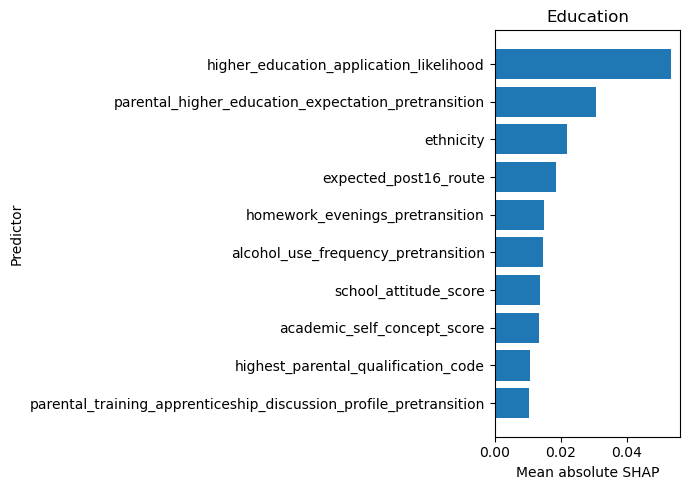

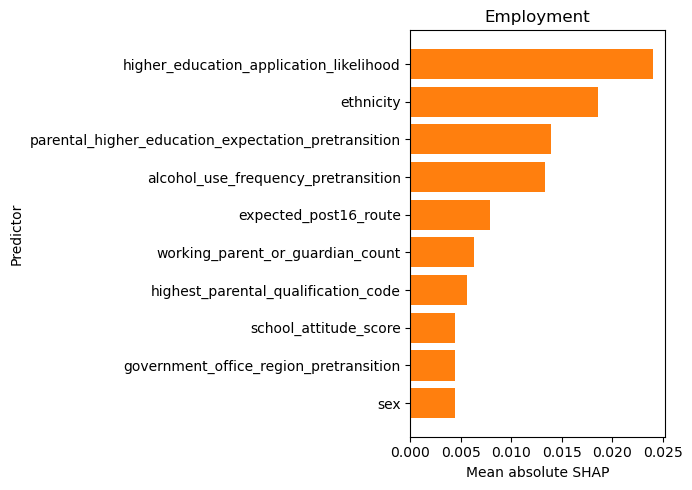

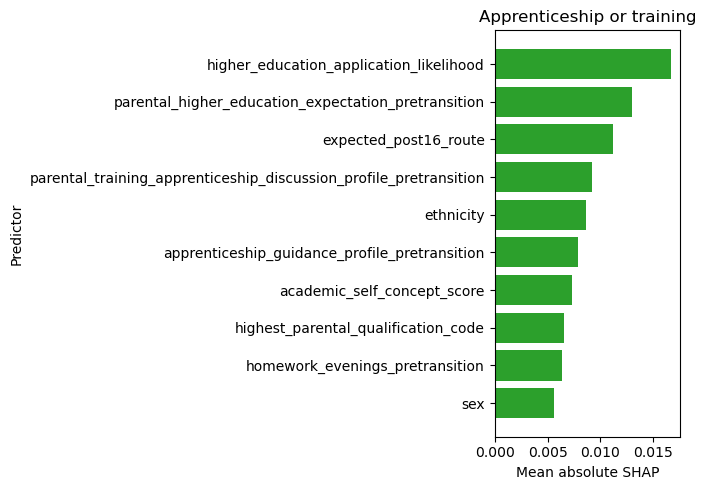

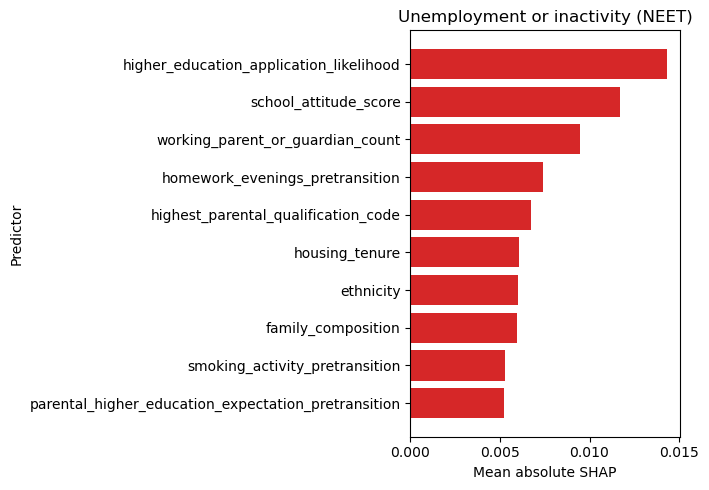

RF importance figures: 4


In [29]:
# 6: Plot the leading RF predictors by destination

# Show the ten largest mean absolute SHAP values for each output.
figure_rows = []

# Use a consistent colour for each destination.
outcome_colours = {
    "Education": "tab:blue",
    "Employment": "tab:orange",
    "Apprenticeship or training": "tab:green",
    "Unemployment or inactivity (NEET)": "tab:red",
}
for outcome in outcome_labels.values():
    current = (
        rf_importance.loc[rf_importance["Outcome"].eq(outcome)]
        .nsmallest(10, "Rank")
        .sort_values("Mean absolute SHAP")
    )

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.barh(
    current["Predictor"],
    current["Mean absolute SHAP"],
    color=outcome_colours[outcome],
    )
    ax.set_xlabel("Mean absolute SHAP")
    ax.set_ylabel("Predictor")
    ax.set_title(outcome)
    fig.tight_layout()

    slug = re.sub(r"[^a-z0-9]+", "_", outcome.lower()).strip("_")
    file_name = f"stage_8_rf_top10_{slug}.png"
    fig.savefig(stage_8_dir / file_name, dpi=150, bbox_inches="tight")
    display(fig)
    plt.close(fig)

    figure_rows.append({"Outcome": outcome, "File": file_name})

importance_figure_register = pd.DataFrame(figure_rows)
importance_figure_register.to_csv(
    stage_8_dir / "stage_8_rf_importance_figure_register.csv",
    index=False,
)

print("RF importance figures:", len(importance_figure_register))


## Part 6: RF direction and shape

Mean absolute SHAP describes attribution magnitude, not direction. Signed SHAP values are therefore examined for the RF top-six predictors within each destination output.

Numeric or ordinal predictors are shown as value-versus-SHAP scatter plots. Categorical predictors are summarised by observed category. These patterns describe the fitted RF prediction function rather than causal relationships.


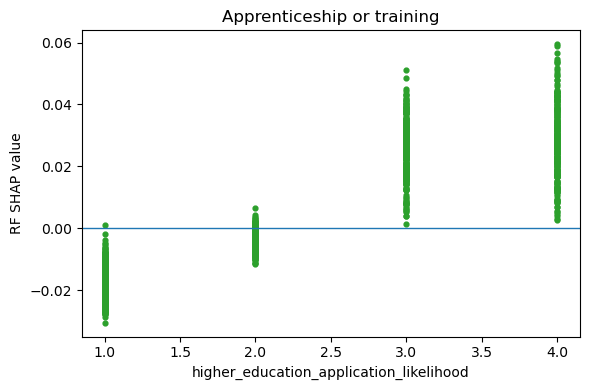

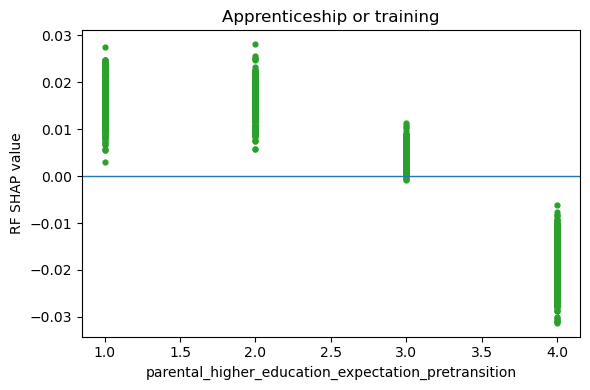

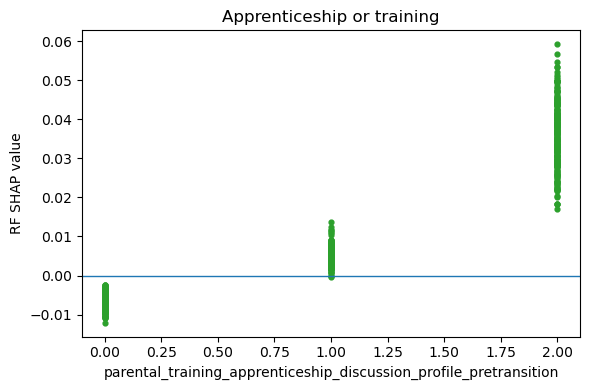

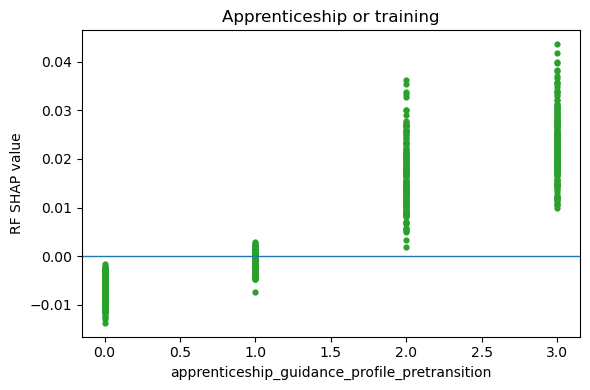

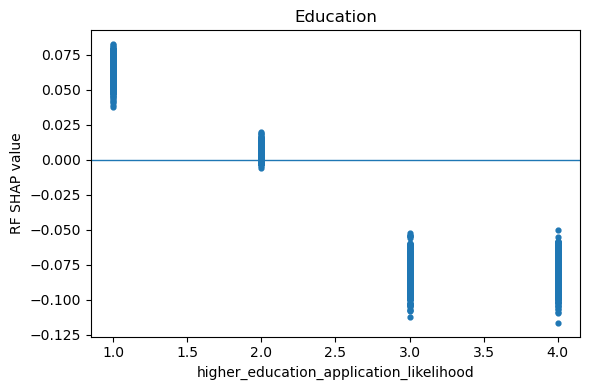

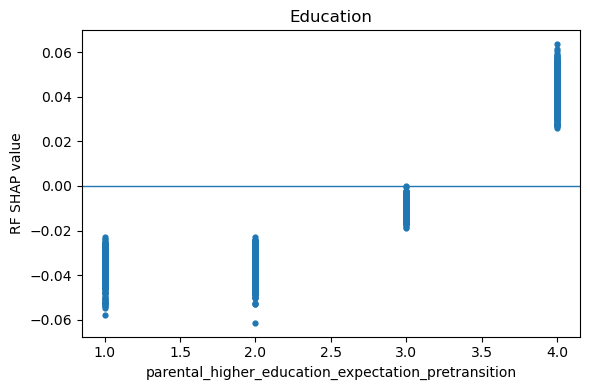

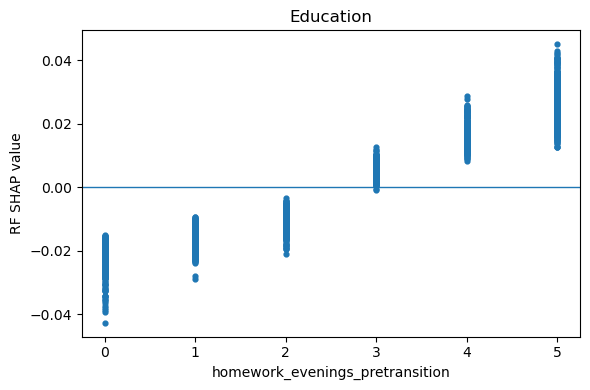

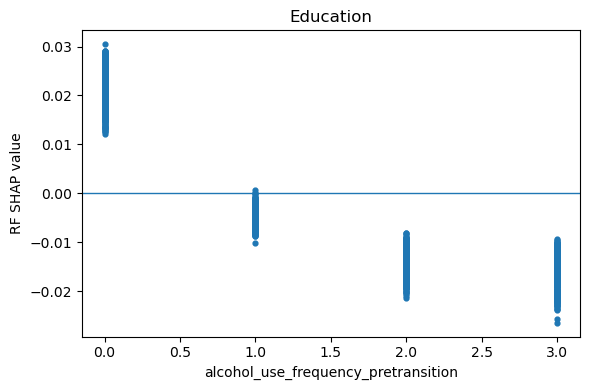

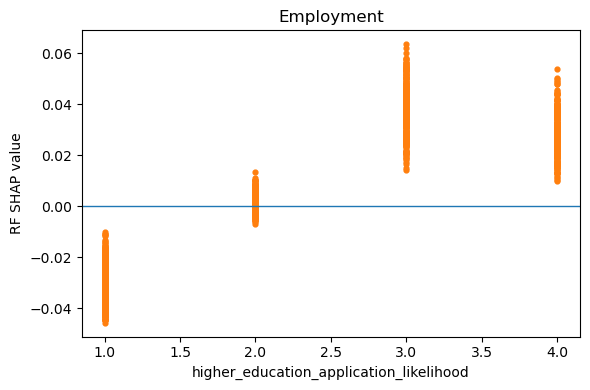

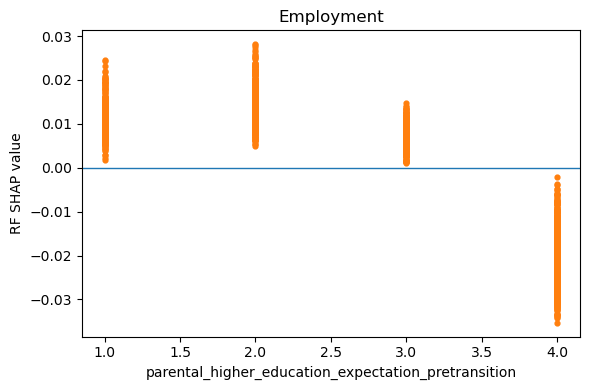

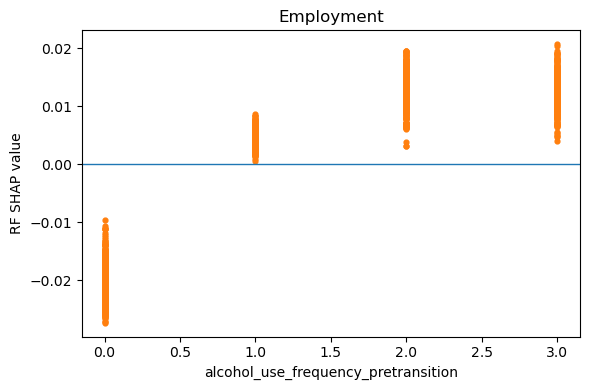

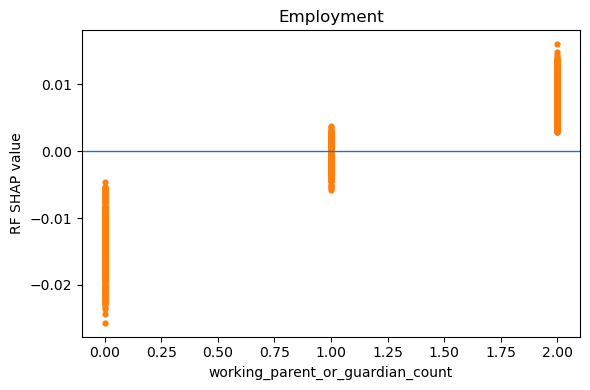

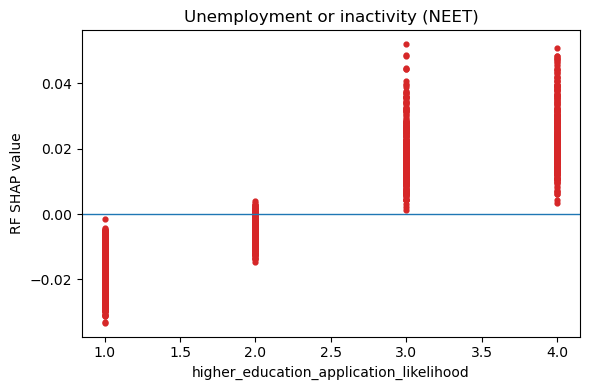

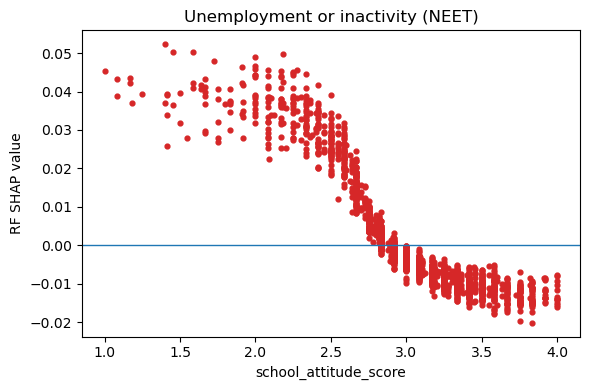

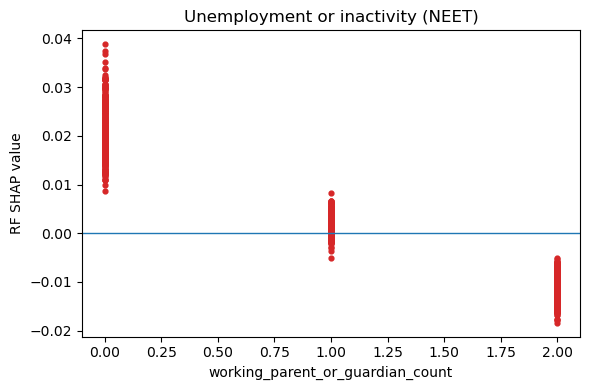

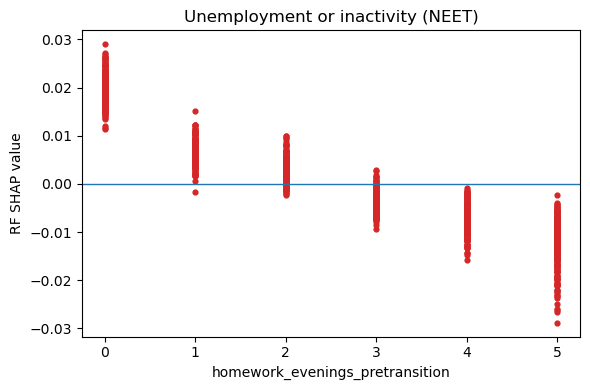

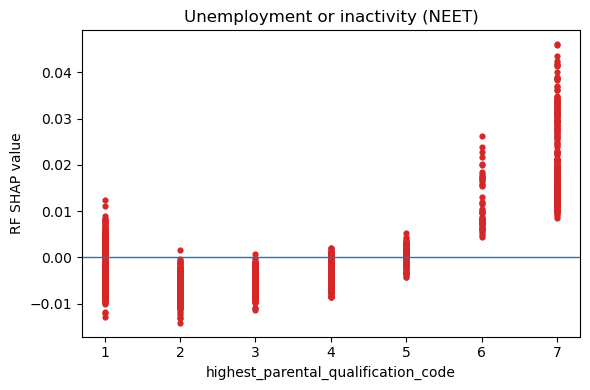

Numeric direction figures: 17


In [30]:
# 1: Create numeric and ordinal RF direction plots

# Plot raw predictor values against signed RF SHAP values.
figure_rows = []

for _, row in rf_top6.iterrows():
    predictor = row["Predictor"]

    if predictor not in numeric:
        continue

    outcome = row["Outcome"]
    class_number = next(
        key for key, value in outcome_labels.items()
        if value == outcome
    )
    predictor_number = predictors.index(predictor)

    plot_data = pd.DataFrame({
        "Value": pd.to_numeric(test[predictor], errors="coerce"),
        "SHAP": rf_grouped_shap[:, predictor_number, class_number],
    }).dropna()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(
    plot_data["Value"],
    plot_data["SHAP"],
    s=12,
    color=outcome_colours[outcome],
    )
    ax.axhline(0, linewidth=1)
    ax.set_xlabel(predictor)
    ax.set_ylabel("RF SHAP value")
    ax.set_title(outcome)
    fig.tight_layout()

    slug = re.sub(
        r"[^a-z0-9]+",
        "_",
        f"{outcome}_{predictor}".lower(),
    ).strip("_")
    file_name = f"stage_8_rf_direction_{slug}.png"
    fig.savefig(stage_8_dir / file_name, dpi=150, bbox_inches="tight")
    display(fig)
    plt.close(fig)

    figure_rows.append({
        "Outcome": outcome,
        "Predictor": predictor,
        "File": file_name,
    })

numeric_figure_register = pd.DataFrame(figure_rows)
numeric_figure_register.to_csv(
    stage_8_dir / "stage_8_rf_numeric_direction_figure_register.csv",
    index=False,
)

print("Numeric direction figures:", len(numeric_figure_register))


In [31]:
# 2: Summarise categorical RF direction

# Summarise signed RF SHAP values within observed categories.
category_rows = []

for _, row in rf_top6.iterrows():
    predictor = row["Predictor"]

    if predictor not in categorical:
        continue

    outcome = row["Outcome"]
    class_number = next(
        key for key, value in outcome_labels.items()
        if value == outcome
    )
    predictor_number = predictors.index(predictor)

    current = pd.DataFrame({
        "Value": test[predictor],
        "SHAP": rf_grouped_shap[:, predictor_number, class_number],
    }).dropna(subset=["Value"])

    summary = (
        current.groupby("Value", dropna=False)["SHAP"]
        .agg(["count", "mean", "median", "std"])
        .reset_index()
    )
    summary["Outcome"] = outcome
    summary["Predictor"] = predictor
    category_rows.append(summary)

categorical_direction = (
    pd.concat(category_rows, ignore_index=True)
    if category_rows
    else pd.DataFrame(columns=[
        "Value", "count", "mean", "median", "std", "Outcome", "Predictor"
    ])
)

categorical_direction.to_csv(
    stage_8_dir / "stage_8_rf_categorical_direction_summary.csv",
    index=False,
)

display(categorical_direction.head(12))


,Value,count,mean,median,std,Outcome,Predictor
0,Full-time employment,59,0.004113,0.003979,0.003393,Apprenticeship or training,expected_post16_route
1,Further-education college,453,0.004157,0.004076,0.003318,Apprenticeship or training,expected_post16_route
2,Other or unspecified full-time education,82,0.007902,0.007536,0.003492,Apprenticeship or training,expected_post16_route
3,"Other, mixed or uncertain route",23,0.006948,0.006607,0.004323,Apprenticeship or training,expected_post16_route
4,School sixth form,809,-0.007692,-0.007396,0.003304,Apprenticeship or training,expected_post16_route
5,Sixth-form college,362,0.001663,0.001382,0.002810,Apprenticeship or training,expected_post16_route
6,Work-based training or employment-training,114,0.097193,0.100422,0.026470,Apprenticeship or training,expected_post16_route
7,Bangladeshi,86,-0.013012,-0.012604,0.003936,Apprenticeship or training,ethnicity
8,Black African,51,-0.014063,-0.014232,0.003458,Apprenticeship or training,ethnicity
9,Black Caribbean,59,-0.012582,-0.012712,0.004666,Apprenticeship or training,ethnicity


## Part 7: MLR and RF interpretation

The six highest-ranked RF predictors for each destination define the focused reporting set. MLR coefficients and class contrasts are examined for the same predictors. RF SHAP values and MLR coefficients are not compared numerically.

In [32]:
# 1: Keep MLR results for the detailed predictor set

# Filter MLR coefficients to the RF-focused predictors.
mlr_detailed_coefficients = mlr_coefficients.loc[
    mlr_coefficients["Original predictor"].isin(detailed_predictors)
].copy()

mlr_detailed_coefficients.to_csv(
    stage_8_dir / "stage_8_mlr_detailed_coefficients.csv",
    index=False,
)

print("Detailed MLR coefficient rows:", len(mlr_detailed_coefficients))


Detailed MLR coefficient rows: 128


In [33]:
# 2: Keep MLR class contrasts for the detailed predictor set

# Filter pairwise MLR contrasts to the same predictors.
mlr_detailed_contrasts = mlr_contrasts.loc[
    mlr_contrasts["Original predictor"].isin(detailed_predictors)
].copy()

mlr_detailed_contrasts.to_csv(
    stage_8_dir / "stage_8_mlr_detailed_class_contrasts.csv",
    index=False,
)

print("Detailed MLR contrast rows:", len(mlr_detailed_contrasts))


Detailed MLR contrast rows: 192


In [34]:
# 3: Create the focused comparison register

# Combine RF ranks with predictor-domain labels for reporting.
comparison_register = (
    rf_top6
    .merge(
        predictor_manifest[["Predictor", "Predictor domain"]],
        on="Predictor",
        how="left",
        validate="many_to_one",
    )
    .sort_values(["Outcome", "Rank"])
    .reset_index(drop=True)
)

comparison_register.to_csv(
    stage_8_dir / "stage_8_mlr_rf_comparison_register.csv",
    index=False,
)

display(comparison_register)


,Outcome,Predictor,Mean absolute SHAP,Rank,Predictor domain
0,Apprenticeship or training,higher_education_application_likelihood,0.016681,1,Educational aspirations and post-16 plans
1,Apprenticeship or training,parental_higher_education_expectation_pretrans...,0.013007,2,"Parental attitudes, support and engagement"
2,Apprenticeship or training,expected_post16_route,0.011199,3,Educational aspirations and post-16 plans
3,Apprenticeship or training,parental_training_apprenticeship_discussion_pr...,0.009238,4,Post-16 social influences and guidance
4,Apprenticeship or training,ethnicity,0.008654,5,Demographic background
5,Apprenticeship or training,apprenticeship_guidance_profile_pretransition,0.007869,6,Post-16 social influences and guidance
6,Education,higher_education_application_likelihood,0.053326,1,Educational aspirations and post-16 plans
7,Education,parental_higher_education_expectation_pretrans...,0.030716,2,"Parental attitudes, support and engagement"
8,Education,ethnicity,0.022000,3,Demographic background
9,Education,expected_post16_route,0.018409,4,Educational aspirations and post-16 plans


## Part 8: Final audit


In [35]:
# 1: Run the Stage 8 audit

# Confirm that the planned interpretation outputs are complete.
required_files = [
    "stage_8_model_reproduction.csv",
    "stage_8_mlr_coefficients.csv",
    "stage_8_mlr_class_contrasts.csv",
    "stage_8_shap_background.csv",
    "stage_8_shap_technical_audit.csv",
    "stage_8_rf_probability_shap.npz",
    "stage_8_rf_feature_mapping.csv",
    "stage_8_rf_shap_importance_by_destination.csv",
    "stage_8_rf_shap_importance_overall.csv",
    "stage_8_rf_top6_by_destination.csv",
    "stage_8_detailed_predictor_register.csv",
    "stage_8_rf_importance_figure_register.csv",
    "stage_8_rf_numeric_direction_figure_register.csv",
    "stage_8_rf_categorical_direction_summary.csv",
    "stage_8_mlr_detailed_coefficients.csv",
    "stage_8_mlr_detailed_class_contrasts.csv",
    "stage_8_mlr_rf_comparison_register.csv",
]

audit_checks = {
    "MLR and RF reproduce Stage 6 predictions and probabilities": (
        prediction_audit[["Predictions match", "Probabilities match"]]
        .all()
        .all()
    ),
    "RF probability TreeSHAP technical check passed": shap_audit["Passed"].all(),
    "RF full probability additivity check passed": shap_full_audit["Passed"].all(),
    "RF feature map contains 69 original predictors": (
        rf_feature_map["Original predictor"].nunique() == 69
    ),
    "RF grouped SHAP contains four outputs": (
        rf_grouped_shap.shape == (1905, 69, 4)
    ),
    "Each destination has six detailed RF predictors": (
        rf_top6.groupby("Outcome").size().eq(6).all()
        and rf_top6["Outcome"].nunique() == 4
    ),
    "All required files are present": all(
        (stage_8_dir / file_name).is_file()
        for file_name in required_files
    ),
}

stage_8_audit = pd.DataFrame({
    "Check": audit_checks.keys(),
    "Passed": audit_checks.values(),
})

display(stage_8_audit)

if not stage_8_audit["Passed"].all():
    raise AssertionError("Stage 8 audit failed.")


,Check,Passed
0,MLR and RF reproduce Stage 6 predictions and p...,True
1,RF probability TreeSHAP technical check passed,True
2,RF full probability additivity check passed,True
3,RF feature map contains 69 original predictors,True
4,RF grouped SHAP contains four outputs,True
5,Each destination has six detailed RF predictors,True
6,All required files are present,True


In [36]:
# 2: Save the final audit

# Save the audit after every check passes.
stage_8_audit.to_csv(
    stage_8_dir / "stage_8_final_audit.csv",
    index=False,
)

print("Stage 8 audit passed.")


Stage 8 audit passed.


## Interpretation

The results show both common and destination-specific predictor patterns across the four age-18 outcomes. The strongest attributions were concentrated in a relatively small group of predictors, but their relative importance differed by destination.